## Search Algorithm: Dijkstra's Algorithm and Uniform-Cost Search In Python

Search algorithm is an algorithm to retrieve information stored within some data structure, or calculated in the search space or a problem domain. \n

Unlike depth first search or breadth first search (BFS), dijkstra's algorithm and uniform cost search (UCS) consider the path cost to the goal. For example, in a road network, the path cost could be the total distance traveled or the total time taken. Dijkstra's algorithm is an algorithm that finds the shortest path from one node to every other node in the graph while UCS finds the shortest path between 2 nodes.


### Uniform Cost Search
UCS expands node with least past g so far. UCS is a modification of BFS. Instead of using the First-In-First-Out queue, it uses a priority queue with past cost g(n) to order the nodes. 

Below is an example with a directed graph, the start node a and the end node d are being highlighted in blue:

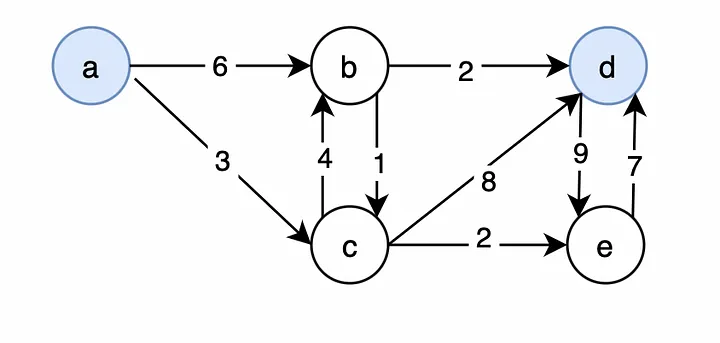 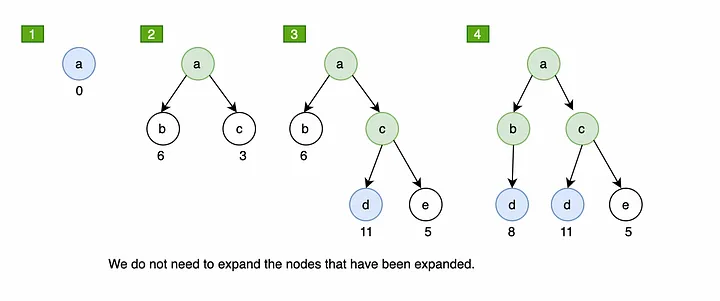

From step by step expansion, it is visible that the path cost is being taken into consideration and it expands the node with the least path cost.
For example, from step 2 to step 3, it expands node c which has the least path cost so far. Moreover, in step 3, even as it reached the destination node d with a total cost of 11 after expanding, since node b's current cost is 6 < 11, so it will continue to expand node b. After expanding node b in step 4, it also reaches destination node d, with a total cost of 8 and there are no more nodes to expand. So the shortest path from a to d = [a -> b -> d] with the total cost  = 8.

After understanding how UCS works, Dijkstra's algorithm is just an algorithm that finds the shortest path to every point instead of a single point.

Evaluation of this algorithm:
1. Time Complexity: How long does it take to find a solution?
    Number of nodes with path cost g = cost of the optimal solution.
        - Equivalent to the number of nodes that pop out from the priority queue
2. Space Complexity: Maximum number of nodes in memory
    Number of nodes with path cost g = cost of the optimal solution
3. Completeness: Does it always find a solution if one exists?
    Yes
4. Optimality: Does it always find the best (least-cost) solution?
    Yes

### Code Implementation
The diagram is a schematic representation of the graph with vertices and edges
V = {a, b, c, d, e}
E = {{a, b, 6}, {a, c, 3}, {b, c, 1}, {c, b, 4}, {b, d, 2}, {c, d, 8}, {c, e,2}, {d, e, 9}, {e,d,7}}

Creating a function that takes weighted edges of the graph which outputs the directed weighted graph

In [3]:
from collections import defaultdict

def generateDirectedGraph(edges):
    graph = defaultdict(dict)
    for u, v, dist in edges:
        graph[u][v] = dist
    return graph
weighted_edges = [['a', 'b', 6], ['a', 'c', 3], ['b', 'c', 1], ['c', 'b', 4], ['b', 'd', 2], ['c', 'd', 8], ['c', 'e', 2], ['d', 'e', 9], ['e', 'd', 7]]
directed_weight_graph = generateDirectedGraph(weighted_edges)
directed_weight_graph

defaultdict(dict,
            {'a': {'b': 6, 'c': 3},
             'b': {'c': 1, 'd': 2},
             'c': {'b': 4, 'd': 8, 'e': 2},
             'd': {'e': 9},
             'e': {'d': 7}})

Creating a function that takes in the directed weighted graph and starting vertex which output the shortest path from starting vertex to very other node in the graph and it's predecessor dictionary (Dijkstra's algorithm)

In [7]:
def dijkstra(graph, src):
    # The only criterium of adding a node to queue is if its distance has changed at the current step.
    queue = [src]
    minDistances = {v: float('inf') for v in graph}
    minDistances[src] = 0
    predecessor = {}

    while queue:
        print('There is still something in the queue', queue)
        currentNode = queue.pop(0)
        print('Current node after popping queue: -> ', currentNode)
        for neighbor in graph[currentNode]:
            print(f"for neighbor {neighbor} in the current place of graph {graph[currentNode][neighbor]}")
            # get potential newDistance from start to neigbor
            newDistance = minDistances[currentNode] + graph[currentNode][neighbor]
            print(f"New distance is {newDistance}")

            # if new distance is shorter to reach neighbor updated to newDistance
            if newDistance < minDistances[neighbor]:
                minDistances[neighbor] = min(newDistance, minDistances[neighbor])
                queue.append(neighbor)
                predecessor[neighbor] = currentNode

    return minDistances, predecessor

shortest_path_cost, predecessor = dijkstra(directed_weight_graph, 'a')
print("Shortest_path_cost from node a to every node  in graph: ", shortest_path_cost, "\npredecessor dictionary:", predecessor)

There is still something in the queue ['a']
Current node after popping queue: ->  a
for neighbor b in the current place of graph 6
New distance is 6
for neighbor c in the current place of graph 3
New distance is 3
There is still something in the queue ['b', 'c']
Current node after popping queue: ->  b
for neighbor c in the current place of graph 1
New distance is 7
for neighbor d in the current place of graph 2
New distance is 8
There is still something in the queue ['c', 'd']
Current node after popping queue: ->  c
for neighbor b in the current place of graph 4
New distance is 7
for neighbor d in the current place of graph 8
New distance is 11
for neighbor e in the current place of graph 2
New distance is 5
There is still something in the queue ['d', 'e']
Current node after popping queue: ->  d
for neighbor e in the current place of graph 9
New distance is 17
There is still something in the queue ['e']
Current node after popping queue: ->  e
for neighbor d in the current place of grap

Exploring an example of what the predecessor dictionary meant. Example, currently from shortest_path_costs output, we know that from node a to node d the shortest_path_cost=8, and how exactly to reach node d with cost of 8 and can be known from it's predecessor dictionary. We can look up the predecessor dictionary starting from destination node d which predecessor is node b.

By following the same logic: node b's predecessor -> node a
Thefore the shortest path between node a and node d is from node a -> node b -> node d

In [9]:
# Uniform cost search - shortest path between source and destination (Greedy)
def UCS(graph, src, dest):
    minDistances, predecessor = dijkstra(graph, src)
    path = []
    currentNode = dest
    while currentNode != src:
        if currentNode not in predecessor:
            print("Path not reachable")
            break
        else:
            path.insert(0, currentNode)
            currentNode = predecessor[currentNode]
    path.insert(0, src)

    if dest in minDistances and minDistances[dest] != float("inf"):
        print('Shortest distance is ' + str(minDistances[dest]))
        print('And the path is ' + str(path))

UCS(directed_weight_graph, 'a', 'd')

There is still something in the queue ['a']
Current node after popping queue: ->  a
for neighbor b in the current place of graph 6
New distance is 6
for neighbor c in the current place of graph 3
New distance is 3
There is still something in the queue ['b', 'c']
Current node after popping queue: ->  b
for neighbor c in the current place of graph 1
New distance is 7
for neighbor d in the current place of graph 2
New distance is 8
There is still something in the queue ['c', 'd']
Current node after popping queue: ->  c
for neighbor b in the current place of graph 4
New distance is 7
for neighbor d in the current place of graph 8
New distance is 11
for neighbor e in the current place of graph 2
New distance is 5
There is still something in the queue ['d', 'e']
Current node after popping queue: ->  d
for neighbor e in the current place of graph 9
New distance is 17
There is still something in the queue ['e']
Current node after popping queue: ->  e
for neighbor d in the current place of grap